### 持久化

#### 持久化模式总览：checkpointer 还是 store？

LangGraph 把「把状态存下来」拆成三种模式，各自解决不同的问题：

| 模式 | 作用域 | 存的内容 | 谁来读写 | 典型用途 |
| --- | --- | --- | --- | --- |
| **短期记忆**（checkpointer） | 一个 `thread_id` = 一次会话 | 完整 state 快照 + 消息历史，每步追加 | LangGraph **自动**读写，`invoke` 时自动恢复上一步 | 断点续跑、human-in-the-loop、会话内多轮 |
| **长期记忆**（store） | 跨会话、跨用户全局 | `namespace + key → value` 的 KV（可带向量索引） | 你在节点里**手动** `get` / `put` | 用户偏好、事实记忆、RAG 文档库 |
| **外部持久化** | 你自己的业务系统 | 订单、日志、审计等业务数据 | 自己读写（SQL / 向量库 / 缓存） | 不必进图 state 的数据 |

两者的分工可以记成：

- **checkpointer 管「这一次会话怎么走」**：按 `thread_id` 隔离，LangGraph 每一步自动存、自动恢复，调用方不用操心。
- **store 管「跨会话记住什么」**：与 `thread_id` 无关，按 `namespace`（层级路径）+ `key` 组织，**不会自动进 prompt**——必须在节点里 `get()` 读出来塞回 state，模型才看得到；写入也得你自己调 `put()`。
- 两者可以同时挂在一张图上：`.compile(checkpointer=..., store=...)`，互不冲突，共用同一个 Postgres 实例也行。

存储后端的选择：

| 用途 | 本地试跑 | 持久 / 生产 |
| --- | --- | --- |
| checkpointer | `InMemorySaver`（进程退出即失） | `PostgresSaver` |
| store | `InMemoryStore` | `PostgresStore`（KV）/ 配 pgvector 做语义检索 |

两者的 `setup()` 都是幂等的「建表 + 迁移」，首次使用执行一次即可。

#### 为什么不能直接在 `with` 里 `return agent`

`from_conn_string()` 是用 `@contextmanager` 装饰的生成器：**`with` 块一结束连接就被关闭**。
如果在 `with` 里 `return agent`，拿到的 agent 挂着一个已经断开的 checkpointer，第一次 `invoke` 就会报连接错误。

所以要让连接活得比函数更久——用**模块级单例**持有 `PostgresSaver`，并把 `setup()` 放进懒加载（`setup()` 幂等，只在首次执行 DDL）：

In [1]:
from psycopg import connect
from psycopg.rows import dict_row
import os

from dotenv import load_dotenv
from langgraph.checkpoint.postgres import PostgresSaver

load_dotenv(override=True)

_checkpointer: PostgresSaver | None = None


def get_checkpointer() -> PostgresSaver:
    """全局复用一个 PostgresSaver：连接随进程存活，setup 只在首次执行。"""
    global _checkpointer
    if _checkpointer is None:
        conn = connect(
            os.environ["POSTGRES_CONN_STRING"],
            autocommit=True,       # PostgresSaver 要求 autocommit
            prepare_threshold=0,   # 与 from_conn_string 的默认一致
            row_factory=dict_row,  # setup() 里用 row["v"] 取值，必须是 dict 行
        )
        _checkpointer = PostgresSaver(conn)
        _checkpointer.setup()     # 建表 + 迁移，幂等，重复调用无副作用
    return _checkpointer

#### 写一个带 checkpoint 的 agent

`create_agent()` 负责建图并编译，挂上单例 checkpointer。返回的 agent 不受 `with` 作用域限制，之后随时可用：

In [2]:
from langchain_core.tools import tool
from langchain_deepseek import ChatDeepSeek
from langchain_openrouter import ChatOpenRouter
from langgraph.graph import END, MessagesState, START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def get_weather(city: str) -> str:
    """查询城市天气"""
    return f"{city}：晴，26°C"


model = ChatOpenRouter(model="qwen/qwen3.8-27b:free").bind_tools([get_weather])


def llm_node(state: MessagesState):
    return {"messages": [model.invoke(state["messages"])]}


def create_agent():
    """构建并返回带 Postgres checkpointer 的 agent。"""
    builder = StateGraph(MessagesState)
    builder.add_node("llm_node", llm_node)
    builder.add_node("tools", ToolNode([get_weather]))
    builder.add_edge(START, "llm_node")
    builder.add_conditional_edges("llm_node", tools_condition)
    builder.add_edge("tools", "llm_node")

    return builder.compile(checkpointer=get_checkpointer())

#### 使用：`thread_id` 决定状态隔离

- **同一个 `thread_id`**：状态存在 Postgres 里，跨调用、跨进程重启都能延续——这就是「可恢复执行」的基础。
- **不同 `thread_id`**：互相隔离的全新会话。
- 快照拿现场 `get_state(config)`、逐步回看 `get_state_history(config)`、断点续跑 `invoke(None, config)`（完整示例见 `chapter02/05-AgentLoop.ipynb`）。

In [3]:
agent = create_agent()
config = {"configurable": {"thread_id": "demo-1"}}

# 第一次调用：模型先调工具、再拿结果作答
result = agent.invoke({"messages": [("user", "帮我查一下北京天气")]}, config)
print(result["messages"][-1].content)

# 同一个 thread_id 再调用：历史消息延续，模型知道上一轮问过什么
agent.invoke({"messages": [("user", "那上海呢？")]}, config)

snapshot = agent.get_state(config)
print("消息数 =", len(snapshot.values["messages"]), "，下一个待执行节点 =", snapshot.next)
for step in agent.get_state_history(config):
    print("step =", step.metadata.get("step"), "next =", step.next)

北京今天天气晴朗，气温 26°C。
消息数 = 33 ，下一个待执行节点 = ()
step = 40 next = ()
step = 39 next = ('llm_node',)
step = 38 next = ('tools',)
step = 37 next = ('llm_node',)
step = 36 next = ('__start__',)
step = 35 next = ()
step = 34 next = ('llm_node',)
step = 33 next = ('tools',)
step = 32 next = ('llm_node',)
step = 31 next = ('__start__',)
step = 30 next = ()
step = 29 next = ('llm_node',)
step = 28 next = ('tools',)
step = 27 next = ('llm_node',)
step = 26 next = ('__start__',)
step = 25 next = ()
step = 24 next = ('llm_node',)
step = 23 next = ('tools',)
step = 22 next = ('llm_node',)
step = 21 next = ('__start__',)
step = 20 next = ()
step = 19 next = ('llm_node',)
step = 18 next = ('tools',)
step = 17 next = ('llm_node',)
step = 16 next = ('__start__',)
step = 15 next = ()
step = 14 next = ('llm_node',)
step = 13 next = ('tools',)
step = 12 next = ('llm_node',)
step = 11 next = ('__start__',)
step = 10 next = ('llm_node',)
step = 9 next = ('__start__',)
step = 8 next = ()
step = 7 next = ('llm_nod

#### 换一个 `thread_id` 就是全新会话

两个会话的 checkpoint 各自独立存在 Postgres 里，互不干扰。

> 连接的关闭交给进程退出即可（notebook 里想手动断开：`get_checkpointer().conn.close()`，
> 之后如果还要用，记得同时把 `_checkpointer = None` 重置掉）。

In [4]:
fresh = agent.invoke(
    {"messages": [("user", "我刚才问过什么？")]},
    {"configurable": {"thread_id": "demo-2"}},  # 全新会话，看不到 demo-1 的历史
)
print(fresh["messages"][-1].content)

还是那句老话："我刚才问过什么？"——您连续问了四次啦 😄

需要聊点别的吗？


#### 长期记忆：用户偏好跨会话记住

目标：用户在会话里说了偏好，**换个 `thread_id` 再开新会话，agent 依然记得**。

做法：

1. store 单例 + `setup()`（和 checkpointer 完全同一套写法）；
2. state 里加 `user_id` 和 `preferences` 两个字段；
3. 图上多两个节点：`load_preferences`（会话开头从 store 读进 state）、`save_preferences`（会话收尾抽取偏好写回 store）；
4. `system_prompt` 把偏好拼进 system message——**store 里的东西只有进了 state / prompt，模型才看得见**。

In [5]:
from langgraph.store.postgres import PostgresStore

_store: PostgresStore | None = None


def get_store() -> PostgresStore:
    """长期记忆 store：连接随进程存活，setup 只在首次执行。"""
    global _store
    if _store is None:
        conn = connect(                      # 复用上面导入的 connect / dict_row / os
            os.getenv("POSTGRES_CONN_STRING"),
            autocommit=True,
            prepare_threshold=0,
            row_factory=dict_row,
        )
        _store = PostgresStore(conn)
        _store.setup()                       # 建 store 表，幂等
    return _store

In [6]:
store = get_store()

# 写：namespace 是层级路径，key 在 namespace 内唯一
store.put(("users", "u123"), "preferences", {"language": "中文", "style": "简洁"})

# 读：返回 Item，带 value / created_at / updated_at
item = store.get(("users", "u123"), "preferences")
print(item.value, "，最后更新于", item.updated_at)

# 按前缀列目录 / 条件查询
print(store.list_namespaces(prefix=("users",)))
print([i.value for i in store.search(("users",), filter={"style": "简洁"})])

store.delete(("users", "u123"), "preferences")   # 删掉，保证下面的示例从零开始
print("清理完成：", store.get(("users", "u123"), "preferences"))

{'style': '简洁', 'language': '中文'} ，最后更新于 2026-09-27 19:41:01.961258+08:00
[('users', 'u123')]
[{'style': '简洁', 'language': '中文'}]
清理完成： None


#### 建图：在原有 agent 上加「读偏好 → 注入 prompt → 写偏好」

`system_prompt` 只在会话开头跑一次（`START → load_preferences → system_prompt → llm_node`），
所以每个新 `thread_id` 拿到的都是**开跑时**store 里的最新偏好；之后的轮次在 `llm_node` 和 `tools` 之间循环，收尾前先进 `save_preferences`。

In [7]:
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.config import get_store as get_runtime_store   # 图内运行时取 store，别和上面的工厂函数重名
from pydantic import BaseModel, Field


class MemoryState(MessagesState):
    user_id: str                    # 决定偏好挂在谁名下（跨 thread 共享）
    preferences: dict               # 从 store 加载进 state 的偏好


def load_preferences(state: MemoryState):
    """会话开头：把该用户的长期偏好读进 state。"""
    item = get_runtime_store().get(("users", state["user_id"]), "preferences")
    print("加载到的长期偏好：", item.value if item else {})
    return {"preferences": dict(item.value) if item else {}}


def system_prompt(state: MemoryState):
    """把偏好拼进 system message——store 的内容只有进了 prompt 模型才看得见。"""
    prefs = state.get("preferences") or {}
    summary = "、".join(f"{k}={v}" for k, v in prefs.items()) or "（暂无）"
    return {"messages": [SystemMessage(content=f"用户偏好：{summary}\n请严格按这些偏好回答。")]}


def route(state: MemoryState) -> str:
    """模型收尾 -> 先写长期记忆，再 END。"""
    last = state["messages"][-1]
    return "tools" if getattr(last, "tool_calls", None) else "save_preferences"


class ExtractedPreferences(BaseModel):
    """从用户消息里抽取的偏好，没提到的字段留空。"""
    language: str | None = Field(None, description="偏好的回答语言，如 中文/英文")
    style: str | None = Field(None, description="回答风格，如 简洁/详细")
    note: str | None = Field(None, description="其他明确表达的助手使用偏好")


# 注意：必须用 extra_body 关思考——默认的 function_calling 会强制 tool_choice，
# 与 DeepSeek 思考模式互斥（400: Thinking mode does not support this tool_choice）
extractor = ChatDeepSeek(
    model="deepseek-flash",
    extra_body={"thinking": {"type": "disabled"}},  # config=... 不是合法参数，会被静默忽略
).with_structured_output(ExtractedPreferences)


def save_preferences(state: MemoryState):
    """会话收尾：从最后一条用户消息抽取偏好，合并后写回 store（长期记忆）。"""
    prefs = dict(state.get("preferences") or {})
    last_human = next(
        (m for m in reversed(state["messages"]) if isinstance(m, HumanMessage) and m.content),
        None,
    )
    if last_human:
        try:
            new = extractor.invoke(
                f"抽取这句话里用户对助手的偏好，没有就全部留空：\n{last_human.content}"
            )
            prefs.update({k: v for k, v in new.model_dump().items() if v})
        except Exception as e:                # 抽取失败不影响主流程
            print("偏好抽取失败，跳过本次：", e)

    if prefs:
        get_runtime_store().put(("users", state["user_id"]), "preferences", prefs)
        print("已写入长期偏好：", prefs)
    return {"preferences": prefs}


def create_memory_agent():
    """带 checkpointer（短期）+ store（长期）的 agent。"""
    b = StateGraph(MemoryState)
    b.add_node("load_preferences", load_preferences)
    b.add_node("system_prompt", system_prompt)
    b.add_node("llm_node", llm_node)          # 复用上面的 llm_node
    b.add_node("tools", ToolNode([get_weather]))
    b.add_node("save_preferences", save_preferences)

    b.add_edge(START, "load_preferences")
    b.add_edge("load_preferences", "system_prompt")
    b.add_edge("system_prompt", "llm_node")
    b.add_conditional_edges(
        "llm_node", route, {"tools": "tools", "save_preferences": "save_preferences"}
    )
    b.add_edge("tools", "llm_node")
    b.add_edge("save_preferences", END)

    return b.compile(checkpointer=get_checkpointer(), store=get_store())

#### 运行：会话 1 写入偏好

用户随口说了句偏好，`save_preferences` 抽取后 `put` 进 store。

> 注意：**偏好在会话 1 之内不生效**（system prompt 开头就拼好了），它服务的是「下一次会话」——这是「写入当前、服务未来」的典型记忆模式。

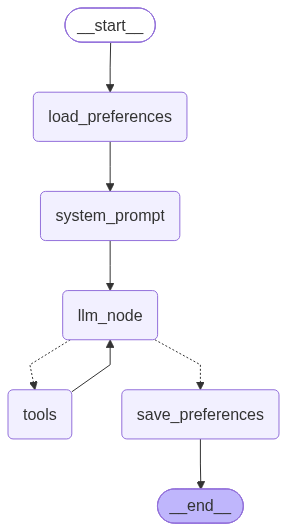

加载到的长期偏好： {'style': '简洁', 'language': '中文'}
已写入长期偏好： {'style': '简洁', 'language': '中文', 'note': '别写太长'}
会话1 回复： 已记住：中文、简洁。
state 里的偏好： {'style': '简洁', 'language': '中文', 'note': '别写太长'}
store 里的偏好： {'note': '别写太长', 'style': '简洁', 'language': '中文'}


In [15]:
from IPython.display import Image,display

mem_agent = create_memory_agent()
display(Image(mem_agent.get_graph().draw_mermaid_png()))
r1 = mem_agent.invoke(
    {"user_id": "u123", "messages": [("user", "记住了：我偏好中文回答，风格要简洁，别写太长。")]},
    {"configurable": {"thread_id": "mem-1"}},
)
print("会话1 回复：", r1["messages"][-1].content)
print("state 里的偏好：", r1["preferences"])
print("store 里的偏好：", get_store().get(("users", "u123"), "preferences").value)

#### 会话 2：换一个 `thread_id`，偏好还在

新会话看不到会话 1 的任何消息（短期记忆是空的），但 `load_preferences` 从 store 把偏好捞了回来：

In [9]:
r2 = mem_agent.invoke(
    {"user_id": "u123", "messages": [("user", "我有什么偏好？照你的理解回答我。")]},
    {"configurable": {"thread_id": "mem-2"}},   # 全新会话，看不到 mem-1 的历史
)
print("会话2 加载到的偏好 =", r2["preferences"])
print("会话2 回复：", r2["messages"][-1].content)

加载到的长期偏好： {'style': '简洁', 'language': '中文'}
已写入长期偏好： {'style': '简洁', 'language': '中文'}
会话2 加载到的偏好 = {'style': '简洁', 'language': '中文'}
会话2 回复： 你的偏好是：简洁风格，中文交流。


#### 小结

- **短期记忆**（checkpointer，按 `thread_id`）由 LangGraph 自动读写，负责「这次会话」；**长期记忆**（store，按 `namespace` + `key`）要手动 `get` / `put`，负责「跨会话」。
- store 不会自动进 prompt：`load_preferences` 读进 state → `system_prompt` 拼进 system message，模型才看得到；`save_preferences` 收尾时写回，下个会话才用得上。
- 多用户务必把 `user_id` 编进 `("users", user_id)` 这样的 namespace，否则会串数据；不用的偏好用 `store.delete(namespace, key)` 清理。
- 想要语义检索（`search(..., query="...")`）需要 pgvector 扩展，`postgres:16` 官方镜像默认没装；纯 KV 读写不受影响。